# Results
This notebook walks through recreation of some key results from [Latham et al. (2000)](https://pubmed.ncbi.nlm.nih.gov/10669496/), it is not exhaustive. I have verified the performance of the model in ways that aren't outlined here. Any and all divergences from the paper that I have found are shown here, and a potential explanation provided. The notebook succesfully recreates the claim of the paper - that firing at low rates is not possible without the presence of endogenously active cells, and the system undergoes a phase transition at a certain threshold value of the fraction of endogenously active cells (here represented through correlation with $\hat{I}_{max}$

In [1]:
%load_ext IPython.extensions.autoreload
%autoreload 2
from neuronsim.simulation import *
from neuronsim.params import *
import numpy as np
import matplotlib.pyplot as plt
import pickle as pkl
import gzip
plt.rcParams.update({
    "text.usetex": True
})

## Figure 7A
Here we show the mean firing rate for Network A without spike adaptation, and the behaviour where $I_{max}$ lies in the regime between $I_{EI}$ and $I_{thresh}$

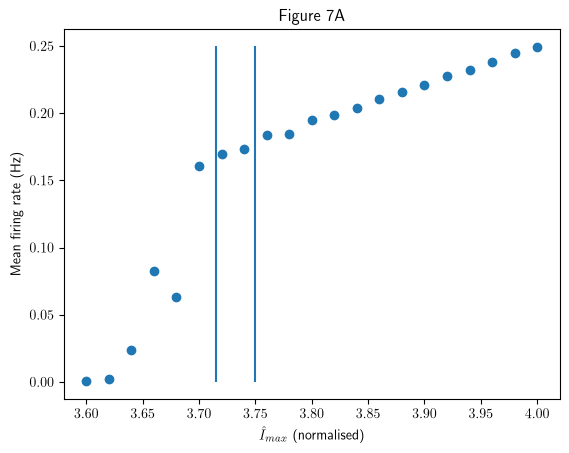

In [2]:
firing_rates = []

for I in np.arange(3.6, 4.02, 0.02):
    cell_params, synaptic_params, network_params = network_A(I, 1.4, 1.1, 0)

    pkl_path = f"pkls/network_A/b_e-1.4/b_i-1.1/delta_g_k_ca-0/I-{I}.pkl.gzip"
    res = None
    
    res = run_sim(cell_params, synaptic_params, network_params)
    with gzip.open(pkl_path, "wb") as f:
        pkl.dump(res, f)
    
    #with gzip.open(pkl_path, "rb") as f:
    #    res = pkl.load(f)

    _, spikes, final_state = res
        
    firing_rate = spikes[:,final_state.neuron_types].sum() / 100 / network_params.n / (1 - network_params.inhib_fraction)
    firing_rates.append(firing_rate)

plt.title("Figure 7A")
plt.ylabel("Mean firing rate (Hz)")
plt.xlabel("$\\hat{I}_{max}$ (normalised)")
plt.scatter(np.arange(3.6, 4.02, 0.02), np.array(firing_rates))
plt.vlines([3.715, 3.75], 0, 0.25)
plt.show()

## Figure 7B
Here we show the mean firing rate for Network A with spike adaptation, and that spike adaptation is required for the bursting regime.

In [3]:
# Setup a Gaussian window for convolutions
def gaus(x, width):
    return 1 / width / np.sqrt(2 * np.pi) * np.exp(-1 / 2 * (x / width)**2)
gaus_window = gaus(np.arange(-30,30), 10)

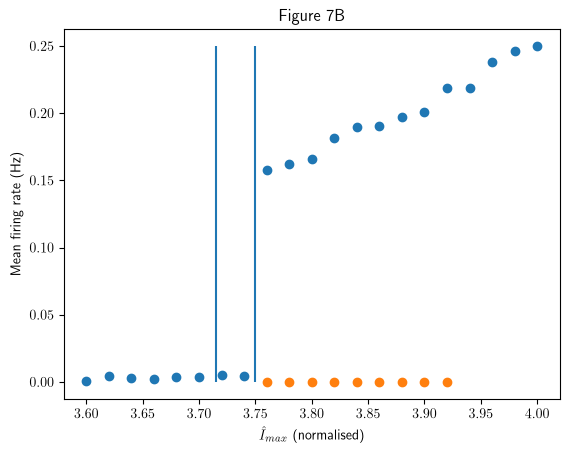

In [4]:
high_firing_rates = []
low_firing_rates = []

for I in np.arange(3.6, 4.02, 0.02):
    cell_params, synaptic_params, network_params = network_A(I, 1.4, 1.1, 0.01)
    pkl_path = f"pkls/network_A/b_e-1.4/b_i-1.1/delta_g_k_ca-0.01/I-{I}.pkl.gzip"
    res = None
    
    res = run_sim(cell_params, synaptic_params, network_params)
    with gzip.open(pkl_path, "wb") as f:
        pkl.dump(res, f)
    
    #with gzip.open(pkl_path, "rb") as f:
    #    res = pkl.load(f)

    t, spikes, final_state = res

    activity = spikes.sum(axis=1)
    # use a rolling average to smooth out noise and find bursting windows
    bursting_filter = (np.convolve(activity, gaus_window) > 0)[29:-30]
    # say somewhat arbitrarily that if we see activity windows after 50s that there exists a stable/metastable state
    # and that if there is a total period of >1s of silence after 50s that that means bursting
    if np.any(bursting_filter[50000:]) and np.sum(~bursting_filter[50000:]) >= 1000:
        bursts = spikes[bursting_filter,]
        firing_rate = bursts[:,final_state.neuron_types].sum() / (bursts.shape[0] / 1000) / network_params.n / (1 - network_params.inhib_fraction)
        high_firing_rates.append(firing_rate)
        low_firing_rates.append(0)
    else:
        firing_rate = spikes[:,final_state.neuron_types].sum() / 100 / network_params.n / (1 - network_params.inhib_fraction)
        high_firing_rates.append(firing_rate)
        low_firing_rates.append(None)
        
plt.title("Figure 7B")
plt.ylabel("Mean firing rate (Hz)")
plt.xlabel("$\\hat{I}_{max}$ (normalised)")
plt.scatter(np.arange(3.6, 4.02, 0.02), np.array(high_firing_rates))
plt.scatter(np.arange(3.6, 4.02, 0.02), np.array(low_firing_rates))
plt.vlines([3.715, 3.75], 0, 0.25)
plt.show()

## Figure 8
Here we show an activity raster for 200 typical neurons in the spike-adapted bursting regime, as well as a voltage trace for neuron 40.

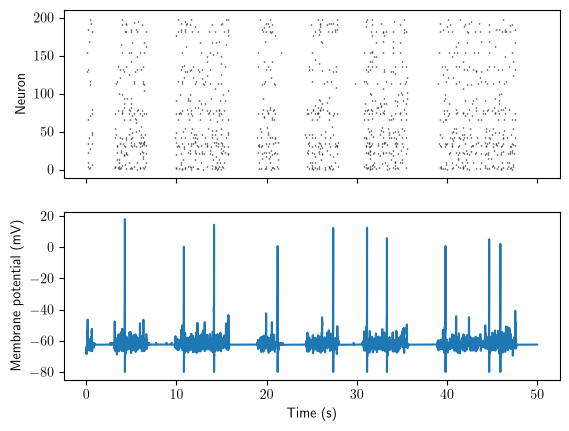

In [5]:
I = 3.8200000000000003
cell_params, synaptic_params, network_params = network_A(I, 1.4, 1.1, 0.01)

res = None
pkl_path = f"pkls/network_A/b_e-1.4/b_i-1.1/delta_g_k_ca-0.01/I-{I}_trace.pkl.gzip"

#res = run_sim(cell_params, synaptic_params, network_params, trace_v=IndexedTraceType(39))
#with gzip.open(pkl_path, "wb") as f:
#    pkl.dump(res, f)

with gzip.open(pkl_path, "rb") as f:
    res = pkl.load(f)
    
t, spikes, _, trace = res

n_i = int(network_params.n * network_params.inhib_fraction)
inhib = spikes[50000:,:40]
excit = spikes[50000:,n_i:n_i + 160]
t = (t[50000:] - 50000) / 1000 # in seconds,from 50s, once the network has settled
reduced_spikes = np.hstack((inhib, excit)).T # now indexes (neuron, time)
t_s = np.ones((200, 1)) * t
reduced_spikes = np.where(reduced_spikes, t_s, None)
reduced_spikes = [x[x.astype(bool)] for x in list(reduced_spikes)]
fig, ax = plt.subplots(2, 1, sharex=True)
ax[0].eventplot(reduced_spikes, colors="black",lineoffsets=1,
                    linelengths=1, linewidths = 1)
ax[1].plot(t, trace[50000:])
ax[0].set_ylabel("Neuron")
ax[1].set_ylabel("Membrane potential (mV)")
plt.xlabel("Time (s)")
plt.show()

## Figure 9
Here we show how connection biases affect the network behaviour at high drive.

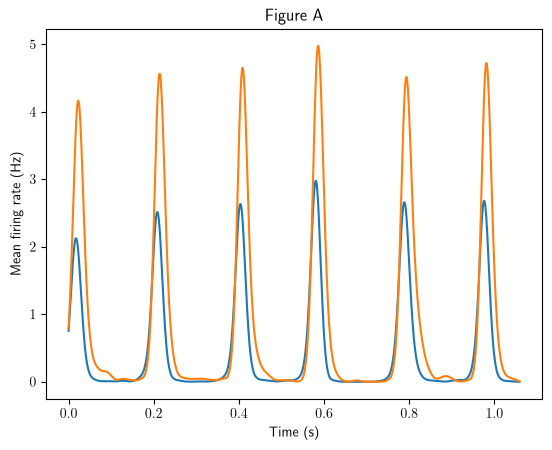

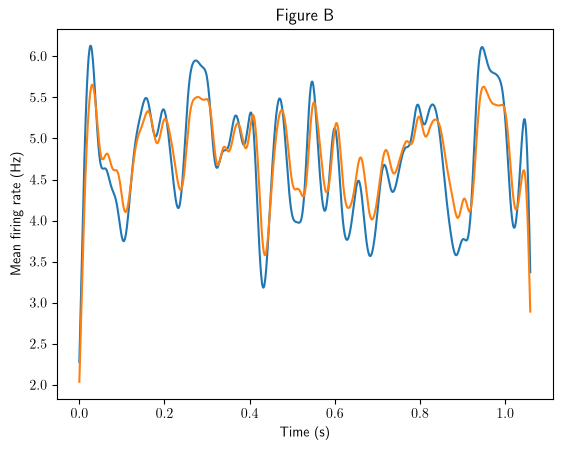

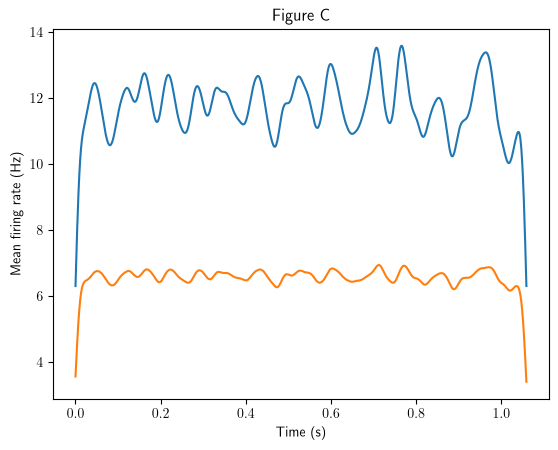

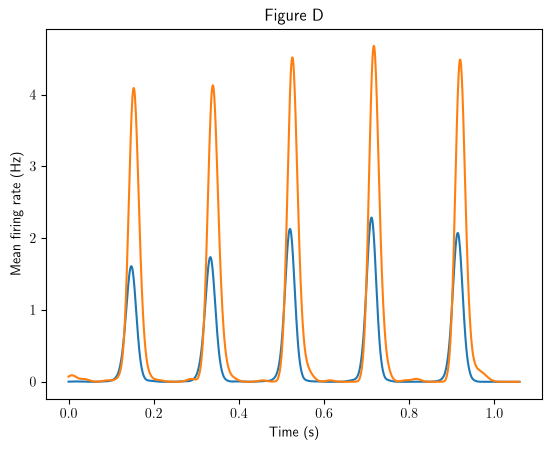

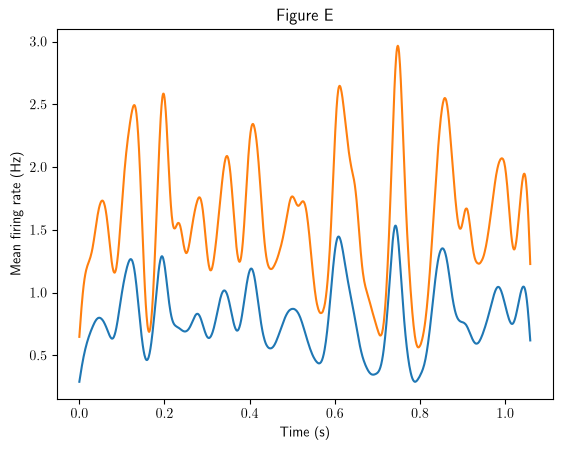

In [6]:
params = {"A": network_A(5, 1.0, 0.8, 0.01), 
          "B": network_A(5, 1.0, 1.0, 0.01), 
          "C": network_A(5, 1.0, 1.2, 0.01), 
          "D": network_A(5, 1.2, 0.8, 0.01), 
          "E": network_A(5, 1.2, 1.0, 0.01)}

for fig in params:
    res = None
    pkl_path = f"pkls/network_A/b_e-{params[fig][2].b_e}/b_i-{params[fig][2].b_i}/delta_g_k_ca-{params[fig][0].delta_g_k_ca}/I-{params[fig][0].i_max}.pkl.gzip"
    
    #res = run_sim(*params[fig])
    #with gzip.open(pkl_path, "wb") as f:
    #    pkl.dump(res, f)

    with gzip.open(pkl_path, "rb") as f:
        res = pkl.load(f)

    t, spikes, _ = res
    n_i = int(params[fig][2].inhib_fraction * params[fig][2].n)
    inhib_rates = np.convolve(gaus_window, spikes[70000:71060,:n_i].sum(axis=1)) / n_i * 1000 # / 10000 * 1000
    excit_rates = np.convolve(gaus_window, spikes[70000:71060,n_i:].sum(axis=1)) / (params[fig][2].n - n_i) * 1000 # / 10000 * 1000
    plt.title(f"Figure {fig}")
    plt.plot((t[70000:71060] - 70000) / 1000, excit_rates[30:-29])
    plt.plot((t[70000:71060] - 70000) / 1000, inhib_rates[30:-29])
    plt.ylabel("Mean firing rate (Hz)")
    plt.xlabel("Time (s)")
    plt.show()

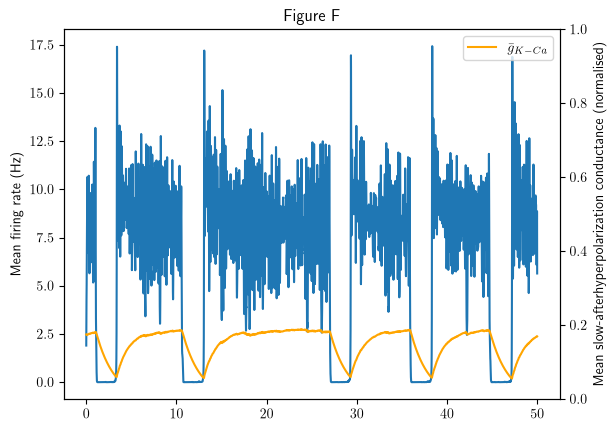

In [7]:
params = network_A(5, 1.2, 1.2, 0.01)

res = None
pkl_path = f"pkls/network_A/b_e-1.2/b_i-1.2/delta_g_k_ca-0.01/I-5_trace.pkl.gzip"
    
#res = run_sim(*params, trace_g_K_Ca=ExcitatoryAverageTraceType())
#with gzip.open(pkl_path, "wb") as f:
#    pkl.dump(res, f)

with gzip.open(pkl_path, "rb") as f:
    res = pkl.load(f)

t, spikes, _, g_K_Ca_trace = res

fig, ax1 = plt.subplots()

n_i = int(params[2].inhib_fraction * params[2].n)
excit_rates = np.convolve(gaus_window, spikes[50000:,n_i:].sum(axis=1)) / (params[2].n - n_i) * 1000 # / 10000 * 1000
plt.title("Figure F")
ax1.plot((t[50000:] - 50000) / 1000, excit_rates[30:-29])
ax1.set_ylabel("Mean firing rate (Hz)")
ax2 = ax1.twinx()
ax2.set_ylim(0,1)
ax2.plot((t[50000:] - 50000) / 1000, g_K_Ca_trace[50000:], color="orange", label="$\\bar{g}_{K-Ca}$")
ax2.set_ylabel("Mean slow-afterhyperpolarization conductance (normalised)")
plt.xlabel("Time (s)")
plt.legend()
plt.show()

## Figure 10
A recreation of Figure 7, with Network B.

_N.B. The firing rates I observe here are consistently ~5x larger than those found in the paper, I believe this is due to the extreme sensitivity of the network in this domain, and the magnification of small variations between my model and that from the study being magnified. In any case the qualitative behaviour of the network is identical, and it would only be a matter of tuning to bring the firing rates in line._

_You also see this in the inconsistency in bursting in 10B, this is hugely dependent on random seed too. I believe this effect would disappear with larger network sizes._

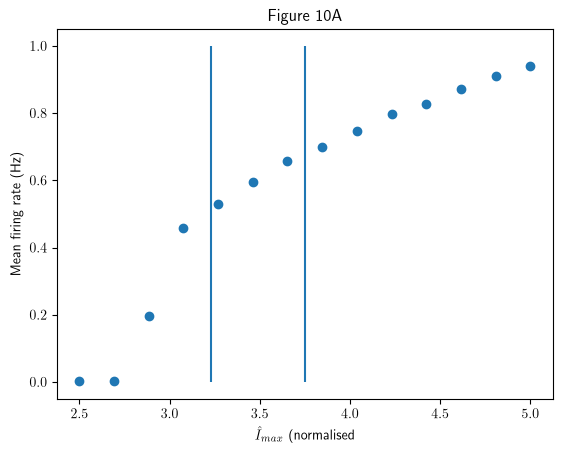

In [8]:
firing_rates = []

for I in np.linspace(2.5, 5, 14):
    cell_params, synaptic_params, network_params = network_B(I, 1.4, 1.0, 0)

    pkl_path = f"pkls/network_B/b_e-1.4/b_i-1.0/delta_g_k_ca-0/I-{I}.pkl.gzip"
    
    res = None
    
    #res = run_sim(cell_params, synaptic_params, network_params, random_seed=1)
    #with gzip.open(pkl_path, "wb") as f:
    #    pkl.dump(res, f)
    
    with gzip.open(pkl_path, "rb") as f:
        res = pkl.load(f)

    _, spikes, final_state = res
        
    firing_rate = spikes[:,final_state.neuron_types].sum() / 100 / network_params.n / (1 - network_params.inhib_fraction)
    firing_rates.append(firing_rate)

plt.title("Figure 10A")
plt.scatter(np.linspace(2.5,5, 14), np.array(firing_rates))
plt.ylabel("Mean firing rate (Hz)")
plt.xlabel("$\\hat{I}_{max}$ (normalised")
plt.vlines([3.23, 3.75], 0, 1)
plt.show()

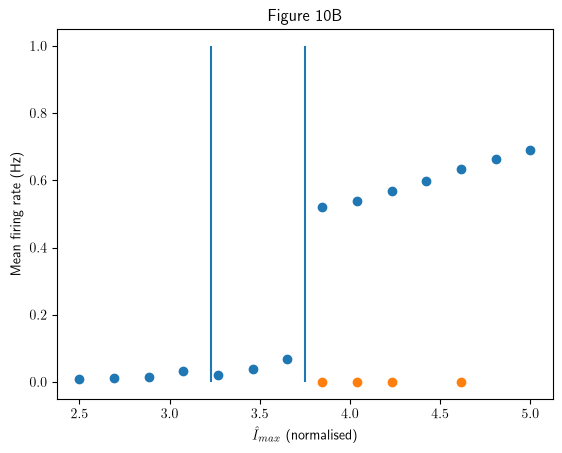

In [9]:
high_firing_rates = []
low_firing_rates = []

for I in np.linspace(2.5, 5, 14):
    cell_params, synaptic_params, network_params = network_B(I, 1.4, 1.0, 0.08)
    
    res = None
    pkl_path = f"pkls/network_B/b_e-1.4/b_i-1.0/delta_g_k_ca-0.08/I-{I}.pkl.gzip"
    
    #res = run_sim(cell_params, synaptic_params, network_params)
    #with gzip.open(pkl_path, "wb") as f:
    #    pkl.dump(res, f)
    
    with gzip.open(pkl_path, "rb") as f:
        res = pkl.load(f)

    t, spikes, final_state = res

    activity = spikes.sum(axis=1)
    # use a rolling average to smooth out noise and find bursting windows
    bursting_filter = (np.convolve(activity, gaus_window) > 0)[29:-30]
    # say somewhat arbitrarily that if we see activity windows after 50s that there exists a stable/metastable state
    # and that if there is a total period of >1s of silence after 50s that that means bursting
    if np.any(bursting_filter[50000:]) and np.sum(~bursting_filter[50000:]) >= 1000:
        bursts = spikes[bursting_filter,]
        firing_rate = bursts[:,final_state.neuron_types].sum() / (bursts.shape[0] / 1000) / network_params.n / (1 - network_params.inhib_fraction)
        high_firing_rates.append(firing_rate)
        low_firing_rates.append(0)
    else:
        firing_rate = spikes[:,final_state.neuron_types].sum() / 100 / network_params.n / (1 - network_params.inhib_fraction)
        high_firing_rates.append(firing_rate)
        low_firing_rates.append(None)
plt.title("Figure 10B")
plt.ylabel("Mean firing rate (Hz)")
plt.xlabel("$\\hat{I}_{max}$ (normalised)")
plt.scatter(np.linspace(2.5,5, 14), np.array(high_firing_rates))
plt.scatter(np.linspace(2.5,5, 14), np.array(low_firing_rates))
plt.vlines([3.23, 3.75], 0, 1)
plt.show()

## Figure 11
A recreation of Figure 9, with Network B.

_Here we see a return to the expected firing rates, which again points to the issue not being with this version of the simulation, but extreme sensitivity to parameters in the regime examined in Figures 7 and 11._

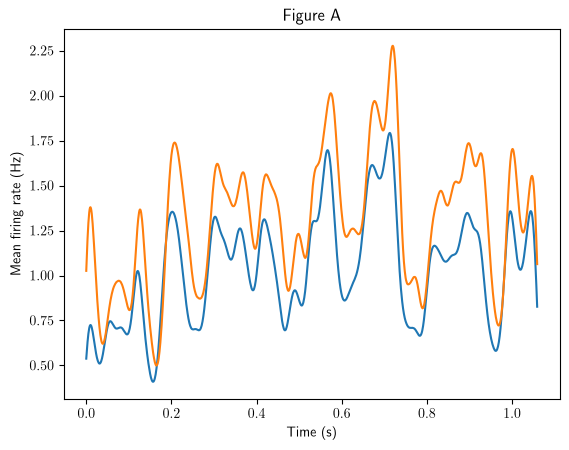

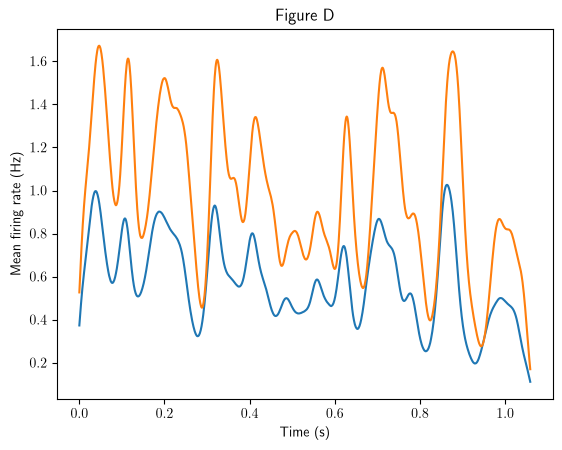

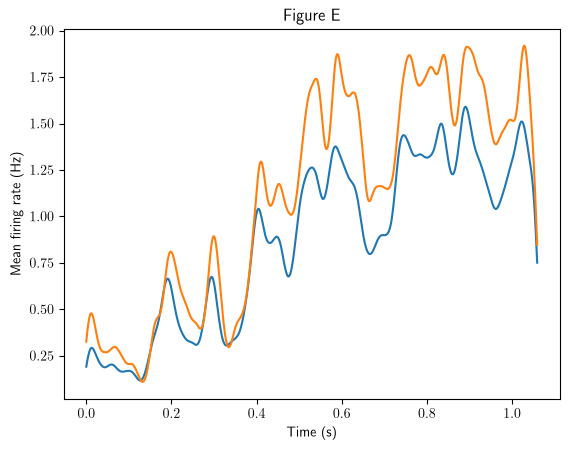

In [10]:
params = {"A": network_B(5, 1.0, 0.8, 0.08), 
          "D": network_B(5, 1.2, 0.8, 0.08), 
          "E": network_B(5, 1.2, 1.0, 0.08)}

for fig in params:
    res = None
    
    pkl_path = f"pkls/network_B/b_e-{params[fig][2].b_e}/b_i-{params[fig][2].b_i}/delta_g_k_ca-{params[fig][0].delta_g_k_ca}/I-{params[fig][0].i_max}.pkl.gzip"
    
    #res = run_sim(*params[fig])
    #with gzip.open(pkl_path, "wb") as f:
    #    pkl.dump(res, f)

    with gzip.open(pkl_path, "rb") as f:
        res = pkl.load(f)

    t, spikes, _ = res
    n_i = int(params[fig][2].inhib_fraction * params[fig][2].n)
    inhib_rates = np.convolve(gaus_window, spikes[70000:71060,:n_i].sum(axis=1)) / n_i * 1000 # / 10000 * 1000
    excit_rates = np.convolve(gaus_window, spikes[70000:71060,n_i:].sum(axis=1)) / (params[fig][2].n - n_i) * 1000 # / 10000 * 1000
    plt.title(f"Figure {fig}")
    plt.plot((t[70000:71060] - 70000) / 1000, excit_rates[30:-29])
    plt.plot((t[70000:71060] - 70000) / 1000, inhib_rates[30:-29])
    plt.ylabel("Mean firing rate (Hz)")
    plt.xlabel("Time (s)")
    plt.show()

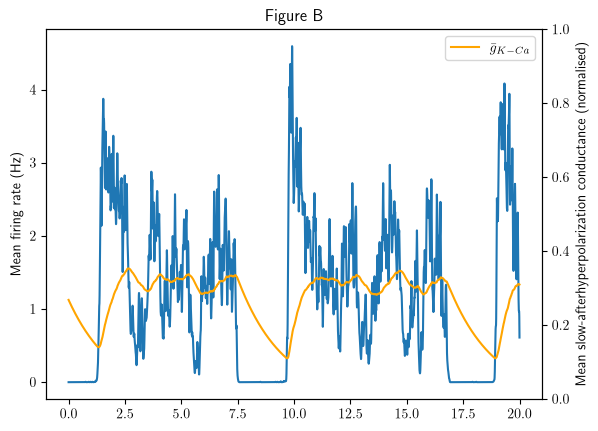

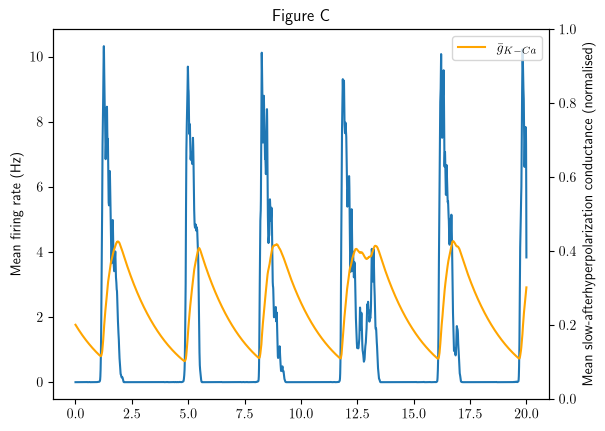

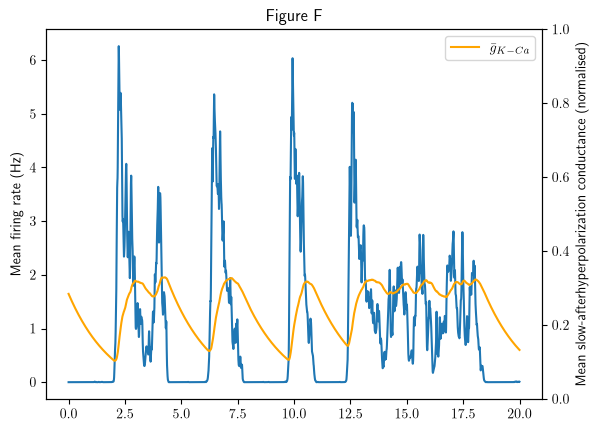

In [11]:
params = {"B": network_B(5, 1.0, 1.0, 0.08), 
          "C": network_B(5, 1.0, 1.2, 0.08), 
          "F": network_B(5, 1.2, 1.2, 0.08)}
        

for fig in params:
    res = None

    pkl_path = f"pkls/network_B/b_e-{params[fig][2].b_e}/b_i-{params[fig][2].b_i}/delta_g_k_ca-{params[fig][0].delta_g_k_ca}/I-{params[fig][0].i_max}.pkl.gzip"
        
    #res = run_sim(*params_s[fig], trace_g_k_ca=ExcitatoryAverageTraceType())
    #with gzip.open(pkl_path, "wb") as f:
    #    pkl.dump(res, f)
    
    with gzip.open(pkl_path, "rb") as f:
        res = pkl.load(f)
    
    t, spikes, _, g_k_ca_trace = res
    
    _, ax1 = plt.subplots()
    
    N_I = int(0.3 * 10000)
    excit_rates = np.convolve(gaus_window, spikes[50000:70000,N_I:].sum(axis=1)) / (10000 - N_I) * 1000 # / 10000 * 1000
    plt.title(f"Figure {fig}")
    ax1.plot((t[50000:70000] - 50000) / 1000, excit_rates[30:-29])
    ax1.set_ylabel("Mean firing rate (Hz)")
    ax2 = ax1.twinx()
    ax2.set_ylim(0,1)
    ax2.plot((t[50000:70000] - 50000) / 1000, g_k_ca_trace[50000:70000], color="orange", label="$\\bar{g}_{K-Ca}$")
    ax2.set_ylabel("Mean slow-afterhyperpolarization conductance (normalised)")
    plt.xlabel("Time (s)")
    plt.legend()
    plt.show()